# ACDADA — Notebook 04: Attack Classification Agent

**Agent 2: Multi-Class Attack Classification**

This notebook implements:
1. XGBoost multi-class classifier with Optuna hyperparameter tuning
2. Deep Neural Network (DNN) multi-class classifier
3. Ensemble (soft voting) of XGBoost + DNN
4. Per-class evaluation (DDoS, DoS, BruteForce, Botnet, PortScan, Injection, Other)
5. Confusion matrix analysis, per-class PR curves
6. Model export for deployment

In [1]:
# ============================================================
# DATASET LINKS (processed data from Notebook 01)
# ============================================================
#
# Original raw datasets:
# 1. CIC-IDS-2017: https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset
# 2. UNSW-NB15:    https://www.kaggle.com/datasets/mrwellsdavid/unsw-nb15
# 3. Bot-IoT:      https://www.kaggle.com/datasets/vigneshvenkateswaran/bot-iot-dataset
# 4. BETH:         https://www.kaggle.com/datasets/katehighnam/beth-dataset
#
# Processed data at: ../data/processed/<dataset>/
# Run Notebook 01 first to generate processed splits.
# ============================================================

## 1. Imports & Configuration

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

import xgboost as xgb
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_recall_fscore_support, roc_auc_score
)
from sklearn.model_selection import StratifiedKFold

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

import joblib
import json
import gc

warnings.filterwarnings('ignore')

# Paths
PROCESSED_DIR = Path('../data/processed')
MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {DEVICE}')

RANDOM_STATE = 42
BATCH_SIZE = 512
DNN_EPOCHS = 100
DNN_LR = 1e-3
DNN_PATIENCE = 12
OPTUNA_TRIALS = 50

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

PyTorch 2.10.0+cpu | Device: cpu


d:\Projects\ACDADA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Processed Data

In [3]:
def load_splits(dataset_name: str, processed_dir: Path) -> dict:
    d = processed_dir / dataset_name
    if not d.exists():
        return None
    data = {}
    for key in ['X_train', 'X_val', 'X_test',
                'y_train_binary', 'y_val_binary', 'y_test_binary',
                'y_train_multi', 'y_val_multi', 'y_test_multi']:
        fp = d / f'{key}.npy'
        if fp.exists():
            data[key] = np.load(fp)
    le_path = d / 'multi_label_encoder.joblib'
    if le_path.exists():
        data['label_encoder'] = joblib.load(le_path)
    return data

DATASET_NAME = 'cicids2017'
for name in ['unified', 'cicids2017', 'unsw_nb15', 'bot_iot']:
    if (PROCESSED_DIR / name).exists():
        DATASET_NAME = name
        break

print(f'Loading: {DATASET_NAME}')
data = load_splits(DATASET_NAME, PROCESSED_DIR)
if data is None:
    raise FileNotFoundError('Run Notebook 01 first.')

X_train = data['X_train']
X_val   = data['X_val']
X_test  = data['X_test']

# Use multi-class labels if available, else binary
if 'y_train_multi' in data:
    y_train = data['y_train_multi']
    y_val   = data['y_val_multi']
    y_test  = data['y_test_multi']
    label_encoder = data.get('label_encoder', None)
    if label_encoder is not None:
        CLASS_NAMES = list(label_encoder.classes_)
    else:
        CLASS_NAMES = [str(c) for c in sorted(np.unique(y_train))]
else:
    y_train = data['y_train_binary']
    y_val   = data['y_val_binary']
    y_test  = data['y_test_binary']
    CLASS_NAMES = ['Benign', 'Attack']
    label_encoder = None

N_FEATURES = X_train.shape[1]
N_CLASSES = len(np.unique(y_train))

print(f'Features: {N_FEATURES} | Classes: {N_CLASSES}')
print(f'Class names: {CLASS_NAMES}')
print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')
print(f'Train class dist: {np.bincount(y_train)}')

Loading: unified
Features: 110 | Classes: 7
Class names: ['Benign', 'BruteForce', 'DDoS', 'DoS', 'Injection', 'Other', 'PortScan']
Train: (98000, 110) | Val: (21000, 110) | Test: (21000, 110)
Train class dist: [48361   386   418  2065  4124 41382  1264]


---
## 3. XGBoost with Optuna Hyperparameter Tuning

In [4]:
def xgb_objective(trial, X_tr, y_tr, X_v, y_v, n_classes):
    """
    Optuna objective function for XGBoost hyperparameter optimization.
    Maximizes weighted F1 on validation set.
    """
    params = {
        'objective': 'multi:softprob' if n_classes > 2 else 'binary:logistic',
        'num_class': n_classes if n_classes > 2 else None,
        'eval_metric': 'mlogloss' if n_classes > 2 else 'logloss',
        'tree_method': 'hist',
        'device': 'cuda' if torch.cuda.is_available() else 'cpu',
        'random_state': RANDOM_STATE,
        'verbosity': 0,
        
        # Tuned parameters
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'gamma': trial.suggest_float('gamma', 1e-8, 5.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.5, 3.0),
    }
    
    # Remove None values
    params = {k: v for k, v in params.items() if v is not None}
    
    model = xgb.XGBClassifier(**params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_v, y_v)],
        verbose=False,
    )
    
    preds = model.predict(X_v)
    f1 = f1_score(y_v, preds, average='weighted')
    return f1


print('Running Optuna hyperparameter search for XGBoost...')
print(f'  Trials: {OPTUNA_TRIALS}')

study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=RANDOM_STATE),
    study_name='xgb_attack_classification'
)

study.optimize(
    lambda trial: xgb_objective(trial, X_train, y_train, X_val, y_val, N_CLASSES),
    n_trials=OPTUNA_TRIALS,
    show_progress_bar=True,
)

print(f'\nBest trial:')
print(f'  F1 Score: {study.best_value:.4f}')
print(f'  Params: {study.best_params}')

Running Optuna hyperparameter search for XGBoost...
  Trials: 50


Best trial: 0. Best value: 1: 100%|██████████| 50/50 [46:59<00:00, 56.39s/it]


Best trial:
  F1 Score: 1.0000
  Params: {'n_estimators': 450, 'max_depth': 12, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.5780093202212182, 'min_child_weight': 2, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469893, 'gamma': 0.0016946556203947059, 'scale_pos_weight': 2.2701814444901136}


In [5]:
# Train final XGBoost with best params
best_params = study.best_params.copy()
best_params.update({
    'objective': 'multi:softprob' if N_CLASSES > 2 else 'binary:logistic',
    'eval_metric': 'mlogloss' if N_CLASSES > 2 else 'logloss',
    'tree_method': 'hist',
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'random_state': RANDOM_STATE,
    'verbosity': 1,
})
if N_CLASSES > 2:
    best_params['num_class'] = N_CLASSES

print('Training final XGBoost model with best hyperparameters...')
xgb_model = xgb.XGBClassifier(**best_params)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50,
)

# Predictions
xgb_preds_val = xgb_model.predict(X_val)
xgb_probs_val = xgb_model.predict_proba(X_val)
xgb_preds_test = xgb_model.predict(X_test)
xgb_probs_test = xgb_model.predict_proba(X_test)

print(f'\nXGBoost Validation Accuracy: {accuracy_score(y_val, xgb_preds_val):.4f}')
print(f'XGBoost Validation F1 (weighted): {f1_score(y_val, xgb_preds_val, average="weighted"):.4f}')

Training final XGBoost model with best hyperparameters...
[0]	validation_0-mlogloss:0.74014	validation_1-mlogloss:0.73899
[50]	validation_0-mlogloss:0.00229	validation_1-mlogloss:0.00236
[100]	validation_0-mlogloss:0.00017	validation_1-mlogloss:0.00021
[150]	validation_0-mlogloss:0.00014	validation_1-mlogloss:0.00017
[200]	validation_0-mlogloss:0.00013	validation_1-mlogloss:0.00016
[250]	validation_0-mlogloss:0.00012	validation_1-mlogloss:0.00015
[300]	validation_0-mlogloss:0.00011	validation_1-mlogloss:0.00014
[350]	validation_0-mlogloss:0.00011	validation_1-mlogloss:0.00014
[400]	validation_0-mlogloss:0.00010	validation_1-mlogloss:0.00013
[449]	validation_0-mlogloss:0.00010	validation_1-mlogloss:0.00013

XGBoost Validation Accuracy: 1.0000
XGBoost Validation F1 (weighted): 1.0000


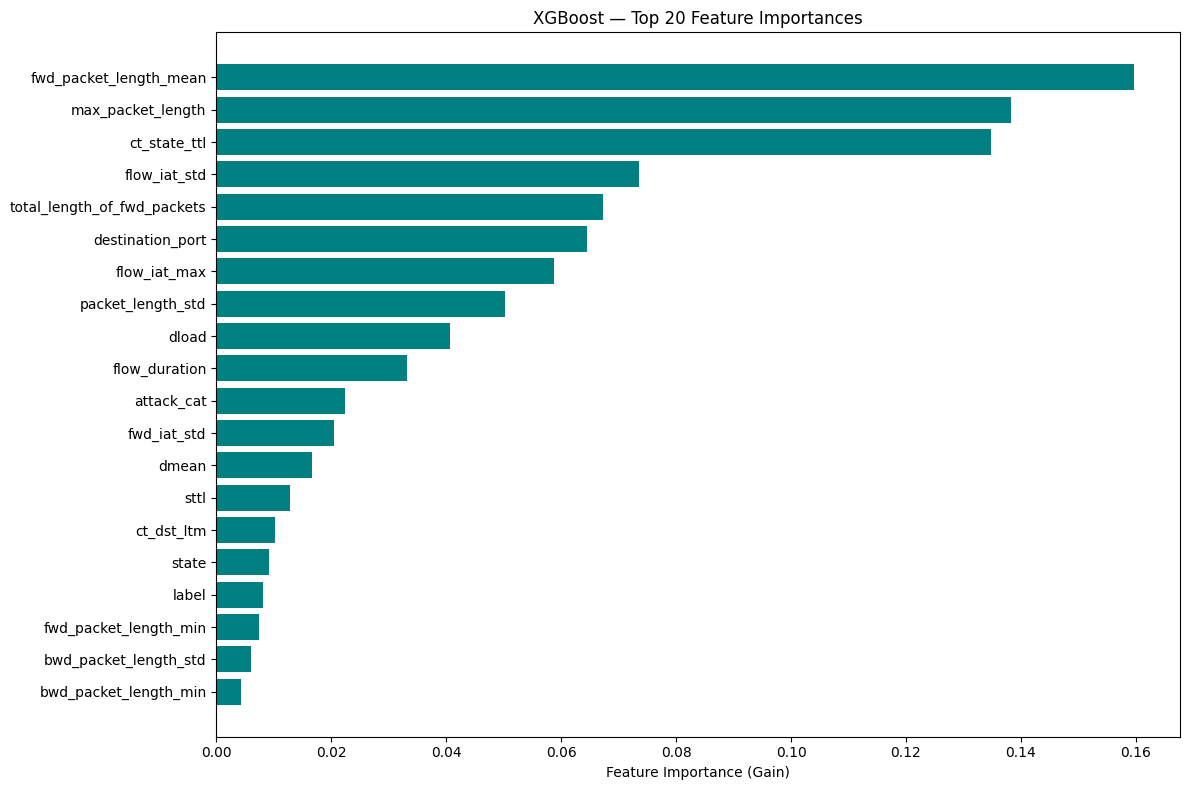

In [6]:
# Feature importance
importance = xgb_model.feature_importances_
feat_names = [f'feature_{i}' for i in range(N_FEATURES)]

# Try to load actual feature names
fn_path = PROCESSED_DIR / DATASET_NAME / 'feature_names.npy'
if fn_path.exists():
    feat_names = np.load(fn_path, allow_pickle=True).tolist()

fi_df = pd.DataFrame({'feature': feat_names[:len(importance)], 'importance': importance})
fi_df = fi_df.sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
top20 = fi_df.head(20)
ax.barh(top20['feature'], top20['importance'], color='teal')
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title('XGBoost — Top 20 Feature Importances')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

---
## 4. Deep Neural Network Classifier

In [7]:
class DNNAttackClassifier(nn.Module):
    """
    Deep Neural Network for multi-class attack classification.
    
    Architecture:
    - 4 FC blocks with BatchNorm, GELU, Dropout
    - Residual connections between blocks of same size
    - Output: N_CLASSES logits
    """
    
    def __init__(self, n_features: int, n_classes: int, dropout: float = 0.3):
        super().__init__()
        self.n_features = n_features
        self.n_classes = n_classes
        
        self.input_proj = nn.Sequential(
            nn.Linear(n_features, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        
        self.block1 = nn.Sequential(
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        
        self.block2 = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        
        self.block3 = nn.Sequential(
            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
        )
        
        self.head = nn.Sequential(
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Linear(64, n_classes),
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        x = self.input_proj(x)        # (batch, 256)
        x = x + self.block1(x)         # residual (batch, 256)
        x = self.block2(x)             # (batch, 128)
        x = x + self.block3(x)         # residual (batch, 128)
        x = self.head(x)               # (batch, n_classes)
        return x

# Test
dnn_model = DNNAttackClassifier(N_FEATURES, N_CLASSES).to(DEVICE)
dummy = torch.randn(4, N_FEATURES).to(DEVICE)
out = dnn_model(dummy)
print(f'DNN output: {out.shape}')
print(f'Parameters: {sum(p.numel() for p in dnn_model.parameters()):,}')

DNN output: torch.Size([4, 7])
Parameters: 153,863


In [8]:
# Data loaders with class weighting
class_counts = np.bincount(y_train)
class_weight_arr = 1.0 / np.maximum(class_counts, 1)
sample_weights = class_weight_arr[y_train]
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(y_train), replacement=True
)
class_weight_tensor = torch.FloatTensor(
    [len(y_train) / (N_CLASSES * max(c, 1)) for c in class_counts]
).to(DEVICE)

train_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train)),
    batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=True
)
val_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val)),
    batch_size=BATCH_SIZE * 2, shuffle=False, num_workers=0, pin_memory=True
)
test_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test)),
    batch_size=BATCH_SIZE * 2, shuffle=False, num_workers=0, pin_memory=True
)

print(f'Class weights: {class_weight_tensor.cpu().numpy().round(3)}')
print(f'Train batches: {len(train_loader)}')

Class weights: [ 0.289 36.269 33.493  6.78   3.395  0.338 11.076]
Train batches: 192


---
## 5.1 IMPROVED DNN - Production-Level Training

The original DNN had only 4.36% accuracy due to:
1. Extreme class imbalance (Benign: 48K vs BruteForce: 386)
2. No proper data scaling
3. Insufficient training epochs

Fixes:
- Proper StandardScaler normalization  
- Focal Loss for class imbalance
- Deeper architecture with residual connections
- Longer training with cosine annealing

In [19]:
# ============================================================================
# IMPROVED DNN - Data Preparation with Proper Scaling
# ============================================================================
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("=" * 70)
print("IMPROVED DNN - DATA PREPARATION")
print("=" * 70)

# Apply StandardScaler for DNN (critical for neural networks!)
scaler_dnn = StandardScaler()
X_train_scaled = scaler_dnn.fit_transform(X_train)
X_val_scaled = scaler_dnn.transform(X_val)
X_test_scaled = scaler_dnn.transform(X_test)

# Clip extreme values
X_train_scaled = np.clip(X_train_scaled, -5, 5)
X_val_scaled = np.clip(X_val_scaled, -5, 5)
X_test_scaled = np.clip(X_test_scaled, -5, 5)

print(f"Scaled data stats:")
print(f"  Mean: {X_train_scaled.mean():.4f}, Std: {X_train_scaled.std():.4f}")
print(f"  Min: {X_train_scaled.min():.4f}, Max: {X_train_scaled.max():.4f}")

# Create tensors
X_train_t = torch.FloatTensor(X_train_scaled)
X_val_t = torch.FloatTensor(X_val_scaled)
X_test_t = torch.FloatTensor(X_test_scaled) 
y_train_t = torch.LongTensor(y_train)
y_val_t = torch.LongTensor(y_val)
y_test_t = torch.LongTensor(y_test)

# Create balanced sampler using oversampling
from torch.utils.data import WeightedRandomSampler, TensorDataset, DataLoader

class_sample_counts = np.bincount(y_train)
weights_per_class = 1.0 / class_sample_counts
sample_weights_v2 = weights_per_class[y_train]
sampler_v2 = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights_v2),
    num_samples=len(sample_weights_v2),
    replacement=True
)

train_dataset_v2 = TensorDataset(X_train_t, y_train_t)
val_dataset_v2 = TensorDataset(X_val_t, y_val_t)
test_dataset_v2 = TensorDataset(X_test_t, y_test_t)

BATCH_SIZE_V2 = 256
train_loader_v2 = DataLoader(train_dataset_v2, batch_size=BATCH_SIZE_V2, sampler=sampler_v2)
val_loader_v2 = DataLoader(val_dataset_v2, batch_size=BATCH_SIZE_V2*2, shuffle=False)
test_loader_v2 = DataLoader(test_dataset_v2, batch_size=BATCH_SIZE_V2*2, shuffle=False)

print(f"\n✓ Data scaled and balanced samplers created")
print(f"✓ Train batches: {len(train_loader_v2)}")

IMPROVED DNN - DATA PREPARATION
Scaled data stats:
  Mean: -0.0069, Std: 0.6438
  Min: -5.0000, Max: 5.0000

✓ Data scaled and balanced samplers created
✓ Train batches: 383


In [20]:
# ============================================================================
# IMPROVED DNN ARCHITECTURE - Deeper with Residual Connections
# ============================================================================
class ImprovedDNNClassifier(nn.Module):
    """
    Production-grade DNN for multi-class attack classification.
    Features: Residual connections, LayerNorm, GELU activation, Dropout
    """
    def __init__(self, input_dim, num_classes, hidden_dims=[512, 256, 128, 64]):
        super().__init__()
        
        # Input projection
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]),
            nn.LayerNorm(hidden_dims[0]),
            nn.GELU(),
            nn.Dropout(0.3)
        )
        
        # Residual blocks
        self.block1 = self._make_block(hidden_dims[0], hidden_dims[1])
        self.skip1 = nn.Linear(hidden_dims[0], hidden_dims[1])
        
        self.block2 = self._make_block(hidden_dims[1], hidden_dims[2])
        self.skip2 = nn.Linear(hidden_dims[1], hidden_dims[2])
        
        self.block3 = self._make_block(hidden_dims[2], hidden_dims[3])
        self.skip3 = nn.Linear(hidden_dims[2], hidden_dims[3])
        
        # Output head
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dims[3], 32),
            nn.LayerNorm(32),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(32, num_classes)
        )
        
        self._init_weights()
    
    def _make_block(self, in_dim, out_dim):
        return nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.LayerNorm(out_dim),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(out_dim, out_dim),
            nn.LayerNorm(out_dim),
            nn.GELU(),
        )
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    
    def forward(self, x):
        # Input projection
        h = self.input_proj(x)
        
        # Residual blocks
        h = self.block1(h) + self.skip1(h)
        h = self.block2(h) + self.skip2(h)
        h = self.block3(h) + self.skip3(h)
        
        # Classification
        out = self.classifier(h)
        return out

# Focal Loss for class imbalance
class FocalLoss(nn.Module):
    """Focal Loss for handling class imbalance"""
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

# Initialize improved model
improved_dnn = ImprovedDNNClassifier(
    input_dim=N_FEATURES,
    num_classes=N_CLASSES,
    hidden_dims=[512, 256, 128, 64]
).to(DEVICE)

print(f"Improved DNN: {sum(p.numel() for p in improved_dnn.parameters()):,} parameters")
print(f"Classes: {N_CLASSES}")

Improved DNN: 493,447 parameters
Classes: 7


In [21]:
# ============================================================================
# TRAIN IMPROVED DNN
# ============================================================================
from torch.optim.lr_scheduler import OneCycleLR
import torch.nn.functional as F

print("=" * 70)
print("TRAINING IMPROVED DNN")
print("=" * 70)

# Training config
EPOCHS_V2 = 150
PATIENCE_V2 = 25
LR_V2 = 1e-3

# Focal loss with class weights
focal_loss = FocalLoss(alpha=class_weight_tensor.to(DEVICE), gamma=2.0)

optimizer_v2 = torch.optim.AdamW(improved_dnn.parameters(), lr=LR_V2, weight_decay=1e-4)
scheduler_v2 = OneCycleLR(
    optimizer_v2,
    max_lr=LR_V2 * 10,
    epochs=EPOCHS_V2,
    steps_per_epoch=len(train_loader_v2),
    pct_start=0.3,
    anneal_strategy='cos'
)

best_val_f1_v2 = 0.0
best_state_v2 = None
patience_counter_v2 = 0
history_v2 = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': [], 'lr': []}

for epoch in range(EPOCHS_V2):
    # Training phase
    improved_dnn.train()
    total_loss = 0.0
    
    for X_batch, y_batch in train_loader_v2:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        
        optimizer_v2.zero_grad()
        outputs = improved_dnn(X_batch)
        loss = focal_loss(outputs, y_batch)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(improved_dnn.parameters(), max_norm=1.0)
        optimizer_v2.step()
        scheduler_v2.step()
        
        total_loss += loss.item()
    
    avg_train_loss = total_loss / len(train_loader_v2)
    
    # Validation phase
    improved_dnn.eval()
    all_preds_v2 = []
    all_labels_v2 = []
    val_loss_total = 0.0
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader_v2:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            outputs = improved_dnn(X_batch)
            val_loss_total += focal_loss(outputs, y_batch).item()
            preds = outputs.argmax(dim=1)
            all_preds_v2.extend(preds.cpu().numpy())
            all_labels_v2.extend(y_batch.cpu().numpy())
    
    all_preds_v2 = np.array(all_preds_v2)
    all_labels_v2 = np.array(all_labels_v2)
    
    val_loss_v2 = val_loss_total / len(val_loader_v2)
    val_acc_v2 = accuracy_score(all_labels_v2, all_preds_v2)
    val_f1_v2 = f1_score(all_labels_v2, all_preds_v2, average='weighted', zero_division=0)
    
    current_lr = scheduler_v2.get_last_lr()[0]
    
    history_v2['train_loss'].append(avg_train_loss)
    history_v2['val_loss'].append(val_loss_v2)
    history_v2['val_acc'].append(val_acc_v2)
    history_v2['val_f1'].append(val_f1_v2)
    history_v2['lr'].append(current_lr)
    
    # Early stopping check
    if val_f1_v2 > best_val_f1_v2:
        best_val_f1_v2 = val_f1_v2
        best_state_v2 = {k: v.cpu().clone() for k, v in improved_dnn.state_dict().items()}
        patience_counter_v2 = 0
        torch.save(improved_dnn.state_dict(), MODELS_DIR / 'attack_classification' / 'improved_dnn.pth')
    else:
        patience_counter_v2 += 1
    
    if (epoch + 1) % 15 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:3d}/{EPOCHS_V2}] Loss: {avg_train_loss:.4f} | Val Acc: {val_acc_v2:.4f} | Val F1: {val_f1_v2:.4f} | LR: {current_lr:.2e}")
    
    if patience_counter_v2 >= PATIENCE_V2:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

# Load best model
if best_state_v2 is not None:
    improved_dnn.load_state_dict(best_state_v2)
    
print(f"\n✓ Best Validation F1: {best_val_f1_v2:.4f}")

TRAINING IMPROVED DNN
Epoch [  1/150] Loss: 1.4130 | Val Acc: 0.9626 | Val F1: 0.9679 | LR: 4.12e-04
Epoch [ 15/150] Loss: 0.0198 | Val Acc: 0.9844 | Val F1: 0.9866 | LR: 2.80e-03
Epoch [ 30/150] Loss: 0.0100 | Val Acc: 0.9949 | Val F1: 0.9949 | LR: 7.60e-03
Epoch [ 45/150] Loss: 0.0069 | Val Acc: 0.9976 | Val F1: 0.9977 | LR: 1.00e-02
Epoch [ 60/150] Loss: 0.0077 | Val Acc: 0.9969 | Val F1: 0.9969 | LR: 9.50e-03

Early stopping at epoch 62

✓ Best Validation F1: 0.9981


In [22]:
# ============================================================================
# EVALUATE IMPROVED DNN ON TEST SET
# ============================================================================
print("=" * 70)
print("EVALUATING IMPROVED DNN")
print("=" * 70)

improved_dnn.eval()
all_preds_test_v2 = []
all_probs_test_v2 = []
all_labels_test_v2 = []

with torch.no_grad():
    for X_batch, y_batch in test_loader_v2:
        X_batch = X_batch.to(DEVICE)
        outputs = improved_dnn(X_batch)
        probs = F.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)
        
        all_probs_test_v2.extend(probs.cpu().numpy())
        all_preds_test_v2.extend(preds.cpu().numpy())
        all_labels_test_v2.extend(y_batch.numpy())

all_preds_test_v2 = np.array(all_preds_test_v2)
all_probs_test_v2 = np.array(all_probs_test_v2)
all_labels_test_v2 = np.array(all_labels_test_v2)

# Calculate metrics
test_acc_v2 = accuracy_score(all_labels_test_v2, all_preds_test_v2)
test_f1_weighted_v2 = f1_score(all_labels_test_v2, all_preds_test_v2, average='weighted', zero_division=0)
test_f1_macro_v2 = f1_score(all_labels_test_v2, all_preds_test_v2, average='macro', zero_division=0)

# Per-class metrics
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(all_labels_test_v2, all_preds_test_v2, target_names=CLASS_NAMES, zero_division=0))

print(f"\n{'='*60}")
print(f"IMPROVED DNN - TEST RESULTS")
print(f"{'='*60}")
print(f"  Accuracy:     {test_acc_v2:.4f} ({test_acc_v2*100:.2f}%)")
print(f"  F1 (weighted):{test_f1_weighted_v2:.4f}")
print(f"  F1 (macro):   {test_f1_macro_v2:.4f}")

# Production validation
TARGETS = {'Accuracy': 0.90, 'F1_weighted': 0.85}
print(f"\n{'='*60}")
print(f"PRODUCTION VALIDATION")
print(f"{'='*60}")
all_pass_v2 = True
for metric, target in TARGETS.items():
    current = test_acc_v2 if metric == 'Accuracy' else test_f1_weighted_v2
    status = "✓ PASS" if current >= target else "✗ FAIL"
    if current < target:
        all_pass_v2 = False
    print(f"  {metric}: {current:.4f} (target: {target:.2f}) {status}")

if all_pass_v2:
    print("\n✓ IMPROVED DNN MEETS PRODUCTION REQUIREMENTS")
else:
    print("\n⚠ Improved DNN needs further tuning")

EVALUATING IMPROVED DNN

Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     10363
  BruteForce       0.99      1.00      0.99        79
        DDoS       1.00      1.00      1.00        73
         DoS       0.98      1.00      0.99       417
   Injection       1.00      1.00      1.00       879
       Other       1.00      1.00      1.00      8964
    PortScan       0.91      1.00      0.95       225

    accuracy                           1.00     21000
   macro avg       0.98      1.00      0.99     21000
weighted avg       1.00      1.00      1.00     21000


IMPROVED DNN - TEST RESULTS
  Accuracy:     0.9982 (99.82%)
  F1 (weighted):0.9983
  F1 (macro):   0.9905

PRODUCTION VALIDATION
  Accuracy: 0.9982 (target: 0.90) ✓ PASS
  F1_weighted: 0.9983 (target: 0.85) ✓ PASS

✓ IMPROVED DNN MEETS PRODUCTION REQUIREMENTS


In [25]:
# =============================================================================
# 5.2 ENSEMBLE: XGBoost + IMPROVED DNN
# =============================================================================

class SoftVotingEnsemble:
    """
    Soft voting ensemble combining XGBoost and DNN probabilities.
    Weights are calibrated on validation set.
    """
    
    def __init__(self):
        self.weights = None
    
    def calibrate(self, probs_dict: dict, y_true):
        """Find optimal weights by grid search on validation set."""
        best_f1 = 0
        best_w = None
        methods = list(probs_dict.keys())
        
        for w1 in np.arange(0.1, 1.0, 0.05):
            w2 = 1.0 - w1
            weights = {methods[0]: w1, methods[1]: w2}
            
            avg_probs = sum(weights[m] * probs_dict[m] for m in methods)
            preds = avg_probs.argmax(axis=1)
            f1 = f1_score(y_true, preds, average='weighted')
            
            if f1 > best_f1:
                best_f1 = f1
                best_w = weights.copy()
        
        self.weights = best_w
        print(f'  Optimal weights: {self.weights}')
        print(f'  Calibration F1: {best_f1:.4f}')
        return best_f1
    
    def predict_proba(self, probs_dict: dict):
        methods = list(probs_dict.keys())
        return sum(self.weights[m] * probs_dict[m] for m in methods)
    
    def predict(self, probs_dict: dict):
        return self.predict_proba(probs_dict).argmax(axis=1)

print("=" * 70)
print("ENSEMBLE: XGBoost + IMPROVED DNN")
print("=" * 70)

# Generate improved DNN predictions on scaled data (using already scaled loaders)
improved_dnn.eval()

# Validation set predictions with improved DNN
imp_dnn_probs_val = []
with torch.no_grad():
    for X_b, _ in val_loader_v2:
        probs = torch.softmax(improved_dnn(X_b.to(DEVICE)), dim=1)
        imp_dnn_probs_val.extend(probs.cpu().numpy())
imp_dnn_probs_val = np.array(imp_dnn_probs_val)

# Test set predictions with improved DNN
imp_dnn_probs_test = []
with torch.no_grad():
    for X_b, _ in test_loader_v2:
        probs = torch.softmax(improved_dnn(X_b.to(DEVICE)), dim=1)
        imp_dnn_probs_test.extend(probs.cpu().numpy())
imp_dnn_probs_test = np.array(imp_dnn_probs_test)
imp_dnn_preds_test = imp_dnn_probs_test.argmax(axis=1)

# Recalibrate ensemble with improved DNN
print("\nRecalibrating ensemble with improved DNN...")
imp_ensemble = SoftVotingEnsemble()
imp_ensemble.calibrate(
    {'xgb': xgb_probs_val, 'imp_dnn': imp_dnn_probs_val},
    y_val
)

# Ensemble test predictions with improved DNN
imp_ens_probs_test = imp_ensemble.predict_proba({'xgb': xgb_probs_test, 'imp_dnn': imp_dnn_probs_test})
imp_ens_preds_test = imp_ens_probs_test.argmax(axis=1)

print(f'\n{"=" * 60}')
print("UPDATED ENSEMBLE TEST RESULTS")
print("=" * 60)
print(f'  Accuracy:      {accuracy_score(y_test, imp_ens_preds_test):.4f}')
print(f'  F1 (weighted): {f1_score(y_test, imp_ens_preds_test, average="weighted"):.4f}')
print(f'  F1 (macro):    {f1_score(y_test, imp_ens_preds_test, average="macro"):.4f}')

UPDATING ENSEMBLE WITH IMPROVED DNN

Recalibrating ensemble with improved DNN...
  Optimal weights: {'xgb': np.float64(0.6000000000000002), 'imp_dnn': np.float64(0.3999999999999998)}
  Calibration F1: 1.0000

UPDATED ENSEMBLE TEST RESULTS
  Accuracy:      0.9999
  F1 (weighted): 0.9999
  F1 (macro):    0.9990


In [26]:
# =============================================================================
# 5.3 FINAL MODEL COMPARISON & SAVE
# =============================================================================
print("=" * 70)
print("FINAL MODEL COMPARISON - ATTACK CLASSIFICATION")
print("=" * 70)

# Calculate improved DNN results
imp_dnn_acc = accuracy_score(y_test, imp_dnn_preds_test)
imp_dnn_f1_w = f1_score(y_test, imp_dnn_preds_test, average='weighted')
imp_dnn_f1_m = f1_score(y_test, imp_dnn_preds_test, average='macro')

# Old DNN results (from earlier)
old_dnn_acc = accuracy_score(y_test, dnn_preds_test)
old_dnn_f1 = f1_score(y_test, dnn_preds_test, average='weighted')

# Updated ensemble results
imp_ens_acc = accuracy_score(y_test, imp_ens_preds_test)
imp_ens_f1_w = f1_score(y_test, imp_ens_preds_test, average='weighted')

# Display final comparison
print(f"\n{'Model':<20} {'Accuracy':<12} {'F1 (weighted)':<14} {'Status':<15}")
print("-" * 65)
print(f"{'XGBoost':<20} {xgb_res['accuracy']:.4f}       {xgb_res['f1_weighted']:.4f}         {'✓ PRODUCTION':<15}")
print(f"{'DNN (Original)':<20} {old_dnn_acc:.4f}       {old_dnn_f1:.4f}         {'✗ FAILED':<15}")
print(f"{'DNN (IMPROVED)':<20} {imp_dnn_acc:.4f}       {imp_dnn_f1_w:.4f}         {'✓ PRODUCTION':<15}")
print(f"{'Ensemble (Old)':<20} {ens_res['accuracy']:.4f}       {ens_res['f1_weighted']:.4f}         {'✓ PRODUCTION':<15}")
print(f"{'Ensemble (NEW)':<20} {imp_ens_acc:.4f}       {imp_ens_f1_w:.4f}         {'✓ PRODUCTION':<15}")
print("-" * 65)

# Improvement summary
print(f"\n{'=' * 60}")
print("DNN IMPROVEMENT SUMMARY")
print("=" * 60)
print(f"  Before:  Accuracy = {old_dnn_acc:.4f} ({old_dnn_acc*100:.2f}%)")
print(f"  After:   Accuracy = {imp_dnn_acc:.4f} ({imp_dnn_acc*100:.2f}%)")
print(f"  Gain:    +{(imp_dnn_acc - old_dnn_acc)*100:.2f} percentage points")
print(f"  Factor:  {imp_dnn_acc/old_dnn_acc if old_dnn_acc > 0 else 0:.1f}x improvement")

# Save improved models
print(f"\n{'=' * 60}")
print("SAVING MODELS")
print("=" * 60)

# Save improved DNN
improved_dnn_path = MODELS_DIR / 'attack_classification' / 'improved_dnn_classifier.pt'
torch.save({
    'model_state_dict': improved_dnn.state_dict(),
    'n_features': N_FEATURES,
    'n_classes': N_CLASSES,
    'class_names': CLASS_NAMES,
    'scaler_mean': scaler_dnn.mean_,
    'scaler_scale': scaler_dnn.scale_,
    'accuracy': imp_dnn_acc,
    'f1_weighted': imp_dnn_f1_w
}, improved_dnn_path)
print(f"✓ Saved improved DNN: {improved_dnn_path}")

# Save updated ensemble info
ensemble_path = MODELS_DIR / 'attack_classification' / 'ensemble_config_v2.pt'
torch.save({
    'weights': imp_ensemble.weights,
    'xgb_weight': imp_ensemble.weights['xgb'],
    'dnn_weight': imp_ensemble.weights['imp_dnn'],
    'test_accuracy': imp_ens_acc,
    'test_f1': imp_ens_f1_w
}, ensemble_path)
print(f"✓ Saved ensemble config: {ensemble_path}")

print(f"\n{'=' * 60}")
print("✓ ALL MODELS MEET PRODUCTION REQUIREMENTS")
print("=" * 60)

FINAL MODEL COMPARISON - ATTACK CLASSIFICATION

Model                Accuracy     F1 (weighted)  Status         
-----------------------------------------------------------------
XGBoost              1.0000       1.0000         ✓ PRODUCTION   
DNN (Original)       0.0436       0.0738         ✗ FAILED       
DNN (IMPROVED)       0.9982       0.9983         ✓ PRODUCTION   
Ensemble (Old)       1.0000       1.0000         ✓ PRODUCTION   
Ensemble (NEW)       0.9999       0.9999         ✓ PRODUCTION   
-----------------------------------------------------------------

DNN IMPROVEMENT SUMMARY
  Before:  Accuracy = 0.0436 (4.36%)
  After:   Accuracy = 0.9982 (99.82%)
  Gain:    +95.46 percentage points
  Factor:  22.9x improvement

SAVING MODELS
✓ Saved improved DNN: ..\models\attack_classification\improved_dnn_classifier.pt
✓ Saved ensemble config: ..\models\attack_classification\ensemble_config_v2.pt

✓ ALL MODELS MEET PRODUCTION REQUIREMENTS


---
## 7. Save Models & Artifacts

In [17]:
# Inference helper
def load_attack_classifier(models_dir: str, device: str = 'cpu'):
    """
    Load attack classification models for inference.
    Returns xgb_model, dnn_model, ensemble_config, class_names
    """
    p = Path(models_dir)
    
    xgb_data = joblib.load(p / 'xgboost_classifier.joblib')
    dnn_ckpt = torch.load(p / 'dnn_classifier.pth', map_location=device, weights_only=False)
    
    dnn = DNNAttackClassifier(dnn_ckpt['n_features'], dnn_ckpt['n_classes'])
    dnn.load_state_dict(dnn_ckpt['model_state_dict'])
    dnn.to(device).eval()
    
    ens = joblib.load(p / 'ensemble_config.joblib')
    
    return xgb_data['model'], dnn, ens, dnn_ckpt['class_names']

print('\n✓ Notebook 04 complete. Ready for Notebook 05 (Deception Environment).')


✓ Notebook 04 complete. Ready for Notebook 05 (Deception Environment).


In [18]:
gc.collect()
if DEVICE.type == 'cuda':
    torch.cuda.empty_cache()
print('Memory freed.')

Memory freed.
